# Final Fleet Model
Kompakte, strukturierte Version mit:
- Parametern + Szenarien oben
- Ergebnis-Dictionary je Szenario (`scenario_results`)
- pro Jahr 5 DataFrames: `exits_df`, `reentries_df`, `missing_df`, `entries_df`, `bestand_df`
- Visualisierung aller Szenarien unten


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# =========================================
# 1) DATEN LADEN
# =========================================
data_dir = Path('/Users/maxbeihofer/Annika Exit Modell/data')

abs_df = pd.read_csv(data_dir / '321-140-17133-26-ABS.csv', sep=';', encoding='latin1')
bestand_df = pd.read_csv(data_dir / '321-140-17133-26-Bestand.csv', sep=';', encoding='latin1')
nzl_df = pd.read_csv(data_dir / '321-140-17133-26-NZL.csv', sep=';', encoding='latin1')

abs_df.columns = abs_df.columns.str.strip()
bestand_df.columns = bestand_df.columns.str.strip()
nzl_df.columns = nzl_df.columns.str.strip()


In [ ]:
# =========================================
# 2) PARAMETER + SZENARIEN
# =========================================
# Struktur: allgemeine Modellparameter + policy-spezifische Parameterblöcke
PARAMS = {
    # -------------------------------------------------
    # A) Allgemeine Modellsteuerung
    # -------------------------------------------------
    'START_YEAR': 2025,          # erstes Simulationsjahr (Startbestand)
    'END_YEAR': 2050,            # letztes Simulationsjahr
    'BIN_WIDTH': 5,              # Altersklassenbreite (z. B. 0-4, 5-9, ...)
    'LOOKBACK_YEARS': 5,         # Historienfenster für pooled Hazard/Reentry-Kalibrierung
    'MAX_REENTRY_RATE': 0.9,     # Obergrenze Reentry-Quote je Zelle
    'MAX_HAZARD_RATE': 1.0,      # Obergrenze Hazard-Rate je Zelle

    # -------------------------------------------------
    # B) Flottengrößen-Pfad (Systemgröße)
    # -------------------------------------------------
    # Prozentuale Änderung des Gesamtbestands von START_YEAR bis END_YEAR.
    # Beispiel: +10 bedeutet 10% mehr Fahrzeuge bis 2050 gegenüber 2025.
    'FLEET_CHANGE_TO_2050_PCT': 10.0,

    # -------------------------------------------------
    # C) Policy: Verbrenneraus (wirkt auf ENTRIES)
    # -------------------------------------------------
    # Zwischen START und END wird der ICE-Anteil bei neuen Entries linear reduziert.
    # Ab ICE_PHASEOUT_YEAR sind ICE-Entries auf 0.
    'ICE_PHASEOUT_START_YEAR': 2026,
    'ICE_PHASEOUT_YEAR': 2035,

    # -------------------------------------------------
    # D) Policy: Diesel-Fahrverbot (wirkt auf BESTAND + ENTRIES)
    # -------------------------------------------------
    # Ab DIESEL_BAN_YEAR: Diesel werden aus dem bestehenden Bestand entfernt
    # und bekommen keinen Entry-Anteil mehr.
    'DIESEL_BAN_YEAR': 2032,

    # -------------------------------------------------
    # E) Policy: Abwrackprämie (wirkt auf EXITS via Hazard)
    # -------------------------------------------------
    # Erhöht die Hazard-Rate nur für Ziel-Antriebsarten (unten), z. B. 5x.
    'SCRAPPAGE_HAZARD_MULTIPLIER': 5,
    # Ziel-Antriebsarten für Hazard-Boost (substring match, lowercase)
    'SCRAPPAGE_TARGET_PATTERNS': ['diesel', 'benzin'],

    # -------------------------------------------------
    # F) Textmuster für Klassifikation
    # -------------------------------------------------
    # ICE-Kandidaten für Entry-Reduktion im Verbrenneraus-Szenario
    'ICE_PATTERNS': ['benzin', 'diesel', 'hybrid', 'plug', 'phev', 'verbren'],
    # Nicht-ICE überschreibt ICE-Match (Sicherheitsliste)
    'NON_ICE_PATTERNS': ['elekt', 'bev', 'fcev', 'wasserstoff'],
    # Diesel-Erkennung für Fahrverbot
    'DIESEL_PATTERNS': ['diesel'],
}

# Szenarioliste (Top-Level im Ergebnis-Dictionary)
SCENARIOS = {
    'baseline': {},                           # keine zusätzliche Policy
    'verbrenneraus': {'ice_phaseout': True},  # Entry-Mix für ICE bis 2035 auf 0
    'diesel_fahrverbot': {'diesel_ban': True},# Diesel ab Ban-Year nicht mehr im Bestand
    'abwrackpraemie': {'scrappage_boost': True}, # Hazard-Boost für Zielgruppen
}

In [4]:
# =========================================
# 3) HILFSFUNKTIONEN + KALIBRIERUNG
# =========================================
def mask_from_patterns(series, patterns):
    s = series.astype(str).str.lower()
    m = pd.Series(False, index=s.index)
    for p in patterns:
        m = m | s.str.contains(p, na=False)
    return m


def build_fleet_total_df(bestand_df, start_year, end_year, pct):
    tmp = bestand_df.copy()
    tmp['Berichtsjahr'] = pd.to_datetime(tmp['Berichtsjahr'].astype(str).str.strip(), format='%d.%m.%Y', errors='coerce').dt.year
    tmp['Anzahl'] = pd.to_numeric(tmp['Anzahl'], errors='coerce')
    n_base = tmp.dropna(subset=['Berichtsjahr', 'Anzahl']).query('Berichtsjahr == @start_year')['Anzahl'].sum()
    n_target = n_base * (1 + pct / 100.0)
    years = np.arange(start_year, end_year + 1)
    t = years - start_year
    T = end_year - start_year
    fleet_total = n_base + (n_target - n_base) * (t / T)
    return pd.DataFrame({'Jahr': years, 'gesamtbestand_target': fleet_total})


def build_hazard_pooled(abs_df, bestand_df, params):
    abg = abs_df.rename(columns={'Berichtsjahr':'Jahr','Jahr der Erstzulassung':'Jahr_der_Erstnutzung','Anzahl':'abgaenge'}).copy()
    abg['Jahr'] = pd.to_numeric(abg['Jahr'], errors='coerce')
    abg['Jahr_der_Erstnutzung'] = pd.to_numeric(abg['Jahr_der_Erstnutzung'], errors='coerce')
    abg['abgaenge'] = pd.to_numeric(abg['abgaenge'], errors='coerce')
    abg = abg.dropna(subset=['Jahr','Segment','Antriebsart','Jahr_der_Erstnutzung','abgaenge']).copy()
    abg['Jahr'] = abg['Jahr'].astype(int)
    abg['Jahr_der_Erstnutzung'] = abg['Jahr_der_Erstnutzung'].astype(int)

    bst = bestand_df.rename(columns={'Berichtsjahr':'Berichtsjahr_raw','Jahr der Erstzulassung':'Jahr_der_Erstnutzung','Anzahl':'bestand'}).copy()
    bst['Berichtsjahr'] = pd.to_datetime(bst['Berichtsjahr_raw'].astype(str).str.strip(), format='%d.%m.%Y', errors='coerce').dt.year
    bst['Jahr_der_Erstnutzung'] = pd.to_numeric(bst['Jahr_der_Erstnutzung'], errors='coerce')
    bst['bestand'] = pd.to_numeric(bst['bestand'], errors='coerce')
    bst = bst.dropna(subset=['Berichtsjahr','Segment','Antriebsart','Jahr_der_Erstnutzung','bestand']).copy()
    bst['Berichtsjahr'] = bst['Berichtsjahr'].astype(int)
    bst['Jahr_der_Erstnutzung'] = bst['Jahr_der_Erstnutzung'].astype(int)
    bst['Jahr'] = bst['Berichtsjahr'] - 1

    latest_year = int(abg['Jahr'].max())
    cutoff = latest_year - params['LOOKBACK_YEARS'] + 1
    abg = abg[(abg['Jahr'] >= cutoff) & (abg['Jahr'] <= latest_year)].copy()
    bst = bst[(bst['Jahr'] >= cutoff) & (bst['Jahr'] <= latest_year)].copy()

    keys = ['Jahr','Segment','Antriebsart','Jahr_der_Erstnutzung']
    abg = abg.groupby(keys, as_index=False)['abgaenge'].sum()
    bst = bst.groupby(keys, as_index=False)['bestand'].sum()

    haz = abg.merge(bst, on=keys, how='left')
    haz['age'] = haz['Jahr'] - haz['Jahr_der_Erstnutzung']
    haz = haz[haz['bestand'].notna() & (haz['bestand'] > 0) & (haz['age'] >= 0)].copy()

    bw = params['BIN_WIDTH']
    haz['age_bin_start'] = (haz['age'] // bw) * bw
    haz['age_bin_end'] = haz['age_bin_start'] + (bw - 1)
    haz['age_bin_5y'] = haz['age_bin_start'].astype(int).astype(str) + '-' + haz['age_bin_end'].astype(int).astype(str)

    out = haz.groupby(['Segment','Antriebsart','age_bin_5y','age_bin_start','age_bin_end'], as_index=False).agg(
        sum_abgaenge_5y=('abgaenge','sum'),
        sum_bestand_5y=('bestand','sum')
    )
    out['hazard_pooled'] = np.where(out['sum_bestand_5y'] > 0, out['sum_abgaenge_5y'] / out['sum_bestand_5y'], 0.0)
    out['hazard_pooled'] = out['hazard_pooled'].fillna(0.0).clip(0.0, params['MAX_HAZARD_RATE'])
    return out


def build_reentry_pooled(abs_df, bestand_df, nzl_df, params):
    abs_c = abs_df.copy()
    abs_c['Jahr'] = pd.to_numeric(abs_c['Berichtsjahr'], errors='coerce')
    abs_c['Jahr_der_Erstnutzung'] = pd.to_numeric(abs_c['Jahr der Erstzulassung'], errors='coerce')
    abs_c['Anzahl'] = pd.to_numeric(abs_c['Anzahl'], errors='coerce')
    abs_c = abs_c.dropna(subset=['Jahr','Segment','Antriebsart','Jahr_der_Erstnutzung','Anzahl'])
    abs_c = abs_c.groupby(['Jahr','Segment','Antriebsart','Jahr_der_Erstnutzung'], as_index=False)['Anzahl'].sum().rename(columns={'Anzahl':'Exits'})
    abs_c['Jahr'] = abs_c['Jahr'].astype(int)
    abs_c['Jahr_der_Erstnutzung'] = abs_c['Jahr_der_Erstnutzung'].astype(int)

    nzl_c = nzl_df.copy()
    nzl_c['Jahr'] = pd.to_numeric(nzl_c['Berichtsjahr'], errors='coerce')
    nzl_c['Anzahl'] = pd.to_numeric(nzl_c['Anzahl'], errors='coerce')
    nzl_c = nzl_c.dropna(subset=['Jahr','Segment','Antriebsart','Anzahl']).copy()
    nzl_c['Jahr'] = nzl_c['Jahr'].astype(int)
    nzl_c['Jahr_der_Erstnutzung'] = nzl_c['Jahr']
    nzl_c = nzl_c.groupby(['Jahr','Segment','Antriebsart','Jahr_der_Erstnutzung'], as_index=False)['Anzahl'].sum().rename(columns={'Anzahl':'Neuzulassungen'})

    bst = bestand_df.copy()
    bst['Berichtsjahr'] = pd.to_datetime(bst['Berichtsjahr'].astype(str).str.strip(), format='%d.%m.%Y', errors='coerce').dt.year
    bst['Jahr_der_Erstnutzung'] = pd.to_numeric(bst['Jahr der Erstzulassung'], errors='coerce')
    bst['Anzahl'] = pd.to_numeric(bst['Anzahl'], errors='coerce')
    bst = bst.dropna(subset=['Berichtsjahr','Segment','Antriebsart','Jahr_der_Erstnutzung','Anzahl'])
    bst = bst.groupby(['Berichtsjahr','Segment','Antriebsart','Jahr_der_Erstnutzung'], as_index=False)['Anzahl'].sum().rename(columns={'Anzahl':'Bestand'})
    bst['Berichtsjahr'] = bst['Berichtsjahr'].astype(int)
    bst['Jahr_der_Erstnutzung'] = bst['Jahr_der_Erstnutzung'].astype(int)

    old = bst.rename(columns={'Berichtsjahr':'Jahr','Bestand':'Bestand_alt'})
    new = bst.rename(columns={'Berichtsjahr':'Jahr_plus_1','Bestand':'Bestand_neu'})
    new['Jahr'] = new['Jahr_plus_1'] - 1
    new = new.drop(columns=['Jahr_plus_1'])

    rec = old.merge(new, on=['Jahr','Segment','Antriebsart','Jahr_der_Erstnutzung'], how='inner')
    rec = rec.merge(abs_c, on=['Jahr','Segment','Antriebsart','Jahr_der_Erstnutzung'], how='left')
    rec = rec.merge(nzl_c, on=['Jahr','Segment','Antriebsart','Jahr_der_Erstnutzung'], how='left')
    rec['Exits'] = rec['Exits'].fillna(0.0)
    rec['Neuzulassungen'] = rec['Neuzulassungen'].fillna(0.0)
    rec['Reentry_raw'] = rec['Bestand_neu'] - rec['Bestand_alt'] + rec['Exits'] - rec['Neuzulassungen']
    rec['Reentry'] = rec['Reentry_raw'].clip(lower=0.0)
    rec['age'] = rec['Jahr'] - rec['Jahr_der_Erstnutzung']
    rec = rec[rec['age'] >= 0].copy()

    bw = params['BIN_WIDTH']
    rec['age_bin_start'] = (rec['age'] // bw) * bw
    rec['age_bin_end'] = rec['age_bin_start'] + (bw - 1)
    rec['age_bin_5y'] = rec['age_bin_start'].astype(int).astype(str) + '-' + rec['age_bin_end'].astype(int).astype(str)

    latest_year = int(rec['Jahr'].max())
    cutoff = latest_year - params['LOOKBACK_YEARS'] + 1
    rec = rec[rec['Jahr'] >= cutoff].copy()

    out = rec.groupby(['Segment','Antriebsart','age_bin_5y','age_bin_start','age_bin_end'], as_index=False).agg(
        sum_reentry_5y=('Reentry','sum'),
        sum_exits_5y=('Exits','sum')
    )
    out['r_reentry_exit_pooled'] = np.where(out['sum_exits_5y'] > 0, out['sum_reentry_5y'] / out['sum_exits_5y'], 0.0)
    out['r_reentry_exit_pooled'] = out['r_reentry_exit_pooled'].fillna(0.0).clip(0.0, params['MAX_REENTRY_RATE'])
    return out


In [ ]:
# =========================================
# 4) MODELL RUNNER + SZENARIO-DICT
# =========================================
hazard_5y_pooled_bins = build_hazard_pooled(abs_df, bestand_df, PARAMS)
reentry_bucket_5y_pooled = build_reentry_pooled(abs_df, bestand_df, nzl_df, PARAMS)
fleet_total_df = build_fleet_total_df(bestand_df, PARAMS['START_YEAR'], PARAMS['END_YEAR'], PARAMS['FLEET_CHANGE_TO_2050_PCT'])


def largest_remainder_allocation(total_int, weights):
    """Allocate integer total across weights using largest remainder method."""
    w = pd.Series(weights, dtype='float64').fillna(0.0)
    if total_int <= 0 or w.sum() <= 0:
        return np.zeros(len(w), dtype=int)
    raw = total_int * (w / w.sum())
    base = np.floor(raw).astype(int)
    remainder = int(total_int - base.sum())
    if remainder > 0:
        order = np.argsort(-(raw - base))
        base.iloc[order[:remainder]] += 1
    return base.to_numpy()


def apply_policy_shares(base_shares, year, scenario_name, params):
    s = base_shares.copy()
    s['share_policy'] = s['share_base']

    if scenario_name == 'verbrenneraus':
        ice = mask_from_patterns(s['Antriebsart'], params['ICE_PATTERNS']) & (~mask_from_patterns(s['Antriebsart'], params['NON_ICE_PATTERNS']))
        start = params['ICE_PHASEOUT_START_YEAR']
        end = params['ICE_PHASEOUT_YEAR']
        if year >= end:
            factor = 0.0
        elif year <= start:
            factor = 1.0
        else:
            factor = (end - year) / (end - start)
        s.loc[ice, 'share_policy'] = s.loc[ice, 'share_policy'] * factor

    if scenario_name == 'diesel_fahrverbot' and year >= params['DIESEL_BAN_YEAR']:
        diesel = mask_from_patterns(s['Antriebsart'], params['DIESEL_PATTERNS'])
        s.loc[diesel, 'share_policy'] = 0.0

    total = s['share_policy'].sum()
    s['share_policy'] = s['share_policy'] / total if total > 0 else s['share_base']
    return s


def run_one_scenario(scenario_name, params):
    # base shares from NZL start year
    nzl_base = nzl_df.copy()
    nzl_base['Berichtsjahr'] = pd.to_numeric(nzl_base['Berichtsjahr'], errors='coerce')
    nzl_base['Anzahl'] = pd.to_numeric(nzl_base['Anzahl'], errors='coerce')
    nzl_base = nzl_base.dropna(subset=['Berichtsjahr','Segment','Antriebsart','Anzahl'])
    nzl_base = nzl_base.query('Berichtsjahr == @params["START_YEAR"]').groupby(['Segment','Antriebsart'], as_index=False)['Anzahl'].sum()
    nzl_base = nzl_base.rename(columns={'Anzahl':'nzl_start'})
    nzl_base['share_base'] = nzl_base['nzl_start'] / nzl_base['nzl_start'].sum()

    # start stock (integer cars)
    stock = bestand_df.copy()
    stock['Berichtsjahr'] = pd.to_datetime(stock['Berichtsjahr'].astype(str).str.strip(), format='%d.%m.%Y', errors='coerce').dt.year
    stock['Jahr_der_Erstnutzung'] = pd.to_numeric(stock['Jahr der Erstzulassung'], errors='coerce')
    stock['Anzahl'] = pd.to_numeric(stock['Anzahl'], errors='coerce')
    stock = stock.dropna(subset=['Berichtsjahr','Segment','Antriebsart','Jahr_der_Erstnutzung','Anzahl'])
    stock = stock.query('Berichtsjahr == @params["START_YEAR"]').groupby(['Segment','Antriebsart','Jahr_der_Erstnutzung'], as_index=False)['Anzahl'].sum().rename(columns={'Anzahl':'bestand'})
    stock['Jahr_der_Erstnutzung'] = stock['Jahr_der_Erstnutzung'].astype(int)
    stock['bestand'] = np.rint(stock['bestand']).astype(int)

    # scenario-specific hazard
    haz = hazard_5y_pooled_bins[['Segment','Antriebsart','age_bin_5y','hazard_pooled']].copy()
    if scenario_name == 'abwrackpraemie':
        m = mask_from_patterns(haz['Antriebsart'], params['SCRAPPAGE_TARGET_PATTERNS'])
        haz.loc[m, 'hazard_pooled'] = haz.loc[m, 'hazard_pooled'] * params['SCRAPPAGE_HAZARD_MULTIPLIER']
    haz['hazard_pooled'] = haz['hazard_pooled'].clip(0.0, params['MAX_HAZARD_RATE'])

    re = reentry_bucket_5y_pooled[['Segment','Antriebsart','age_bin_5y','r_reentry_exit_pooled']].copy()

    out = {}
    bw = params['BIN_WIDTH']

    for year in range(params['START_YEAR'], params['END_YEAR']):
        next_year = year + 1

        work = stock.copy()
        work['age'] = year - work['Jahr_der_Erstnutzung']
        work = work[work['age'] >= 0].copy()
        work['age_bin_start'] = (work['age'] // bw) * bw
        work['age_bin_end'] = work['age_bin_start'] + (bw - 1)
        work['age_bin_5y'] = work['age_bin_start'].astype(int).astype(str) + '-' + work['age_bin_end'].astype(int).astype(str)

        exits_df = work.merge(haz, on=['Segment','Antriebsart','age_bin_5y'], how='left')
        exits_df['hazard_pooled'] = exits_df['hazard_pooled'].fillna(0.0)

        # Integer exits/reentries per row
        exits_df['exits'] = np.rint(exits_df['bestand'] * exits_df['hazard_pooled']).astype(int)
        exits_df['exits'] = exits_df[['exits', 'bestand']].min(axis=1)
        exits_df['survivors_pre_reentry'] = exits_df['bestand'] - exits_df['exits']

        reentries_df = exits_df.merge(re, on=['Segment','Antriebsart','age_bin_5y'], how='left')
        reentries_df['r_reentry_exit_pooled'] = reentries_df['r_reentry_exit_pooled'].fillna(0.0)
        reentries_df['reentries'] = np.rint(reentries_df['exits'] * reentries_df['r_reentry_exit_pooled']).astype(int)
        reentries_df['reentries'] = reentries_df[['reentries', 'exits']].min(axis=1)
        reentries_df['bestand_existing_next'] = reentries_df['survivors_pre_reentry'] + reentries_df['reentries']

        if scenario_name == 'diesel_fahrverbot' and next_year >= params['DIESEL_BAN_YEAR']:
            dm = mask_from_patterns(reentries_df['Antriebsart'], params['DIESEL_PATTERNS'])
            reentries_df.loc[dm, 'bestand_existing_next'] = 0

        target_next = int(np.rint(float(fleet_total_df.loc[fleet_total_df['Jahr'] == next_year, 'gesamtbestand_target'].iloc[0])))
        existing_next = int(reentries_df['bestand_existing_next'].sum())
        missing = max(0, target_next - existing_next)
        missing_df = pd.DataFrame({'Jahr':[next_year],'target_gesamtbestand':[target_next],'bestand_existing':[existing_next],'fehlende_autos':[missing]})

        shares_year = apply_policy_shares(nzl_base[['Segment','Antriebsart','share_base']], next_year, scenario_name, params)
        entries_df = shares_year.copy()
        entries_df['entries'] = largest_remainder_allocation(missing, entries_df['share_policy'])
        entries_df['Jahr_der_Erstnutzung'] = next_year

        existing_df = reentries_df[['Segment','Antriebsart','Jahr_der_Erstnutzung','bestand_existing_next']].rename(columns={'bestand_existing_next':'bestand'})
        new_df = entries_df[['Segment','Antriebsart','Jahr_der_Erstnutzung','entries']].rename(columns={'entries':'bestand'})
        bestand_df_next = pd.concat([existing_df, new_df], ignore_index=True)
        bestand_df_next = bestand_df_next.groupby(['Segment','Antriebsart','Jahr_der_Erstnutzung'], as_index=False)['bestand'].sum()
        bestand_df_next['bestand'] = np.rint(bestand_df_next['bestand']).astype(int)
        bestand_df_next['Berichtsjahr'] = next_year
        bestand_df_next['age'] = bestand_df_next['Berichtsjahr'] - bestand_df_next['Jahr_der_Erstnutzung']

        out[next_year] = {
            'exits_df': exits_df.copy(),
            'reentries_df': reentries_df.copy(),
            'missing_df': missing_df.copy(),
            'entries_df': entries_df.copy(),
            'bestand_df': bestand_df_next.copy(),
        }

        stock = bestand_df_next[['Segment','Antriebsart','Jahr_der_Erstnutzung','bestand']].copy()

    return out


scenario_results = {}
for scen in SCENARIOS.keys():
    scenario_results[scen] = run_one_scenario(scen, PARAMS)

print('Szenarien:', list(scenario_results.keys()))
print('Jahre:', min(scenario_results['baseline'].keys()), '-', max(scenario_results['baseline'].keys()))

Szenarien: ['baseline', 'verbrenneraus', 'diesel_fahrverbot', 'abwrackpraemie']
Jahre: 2026 - 2050


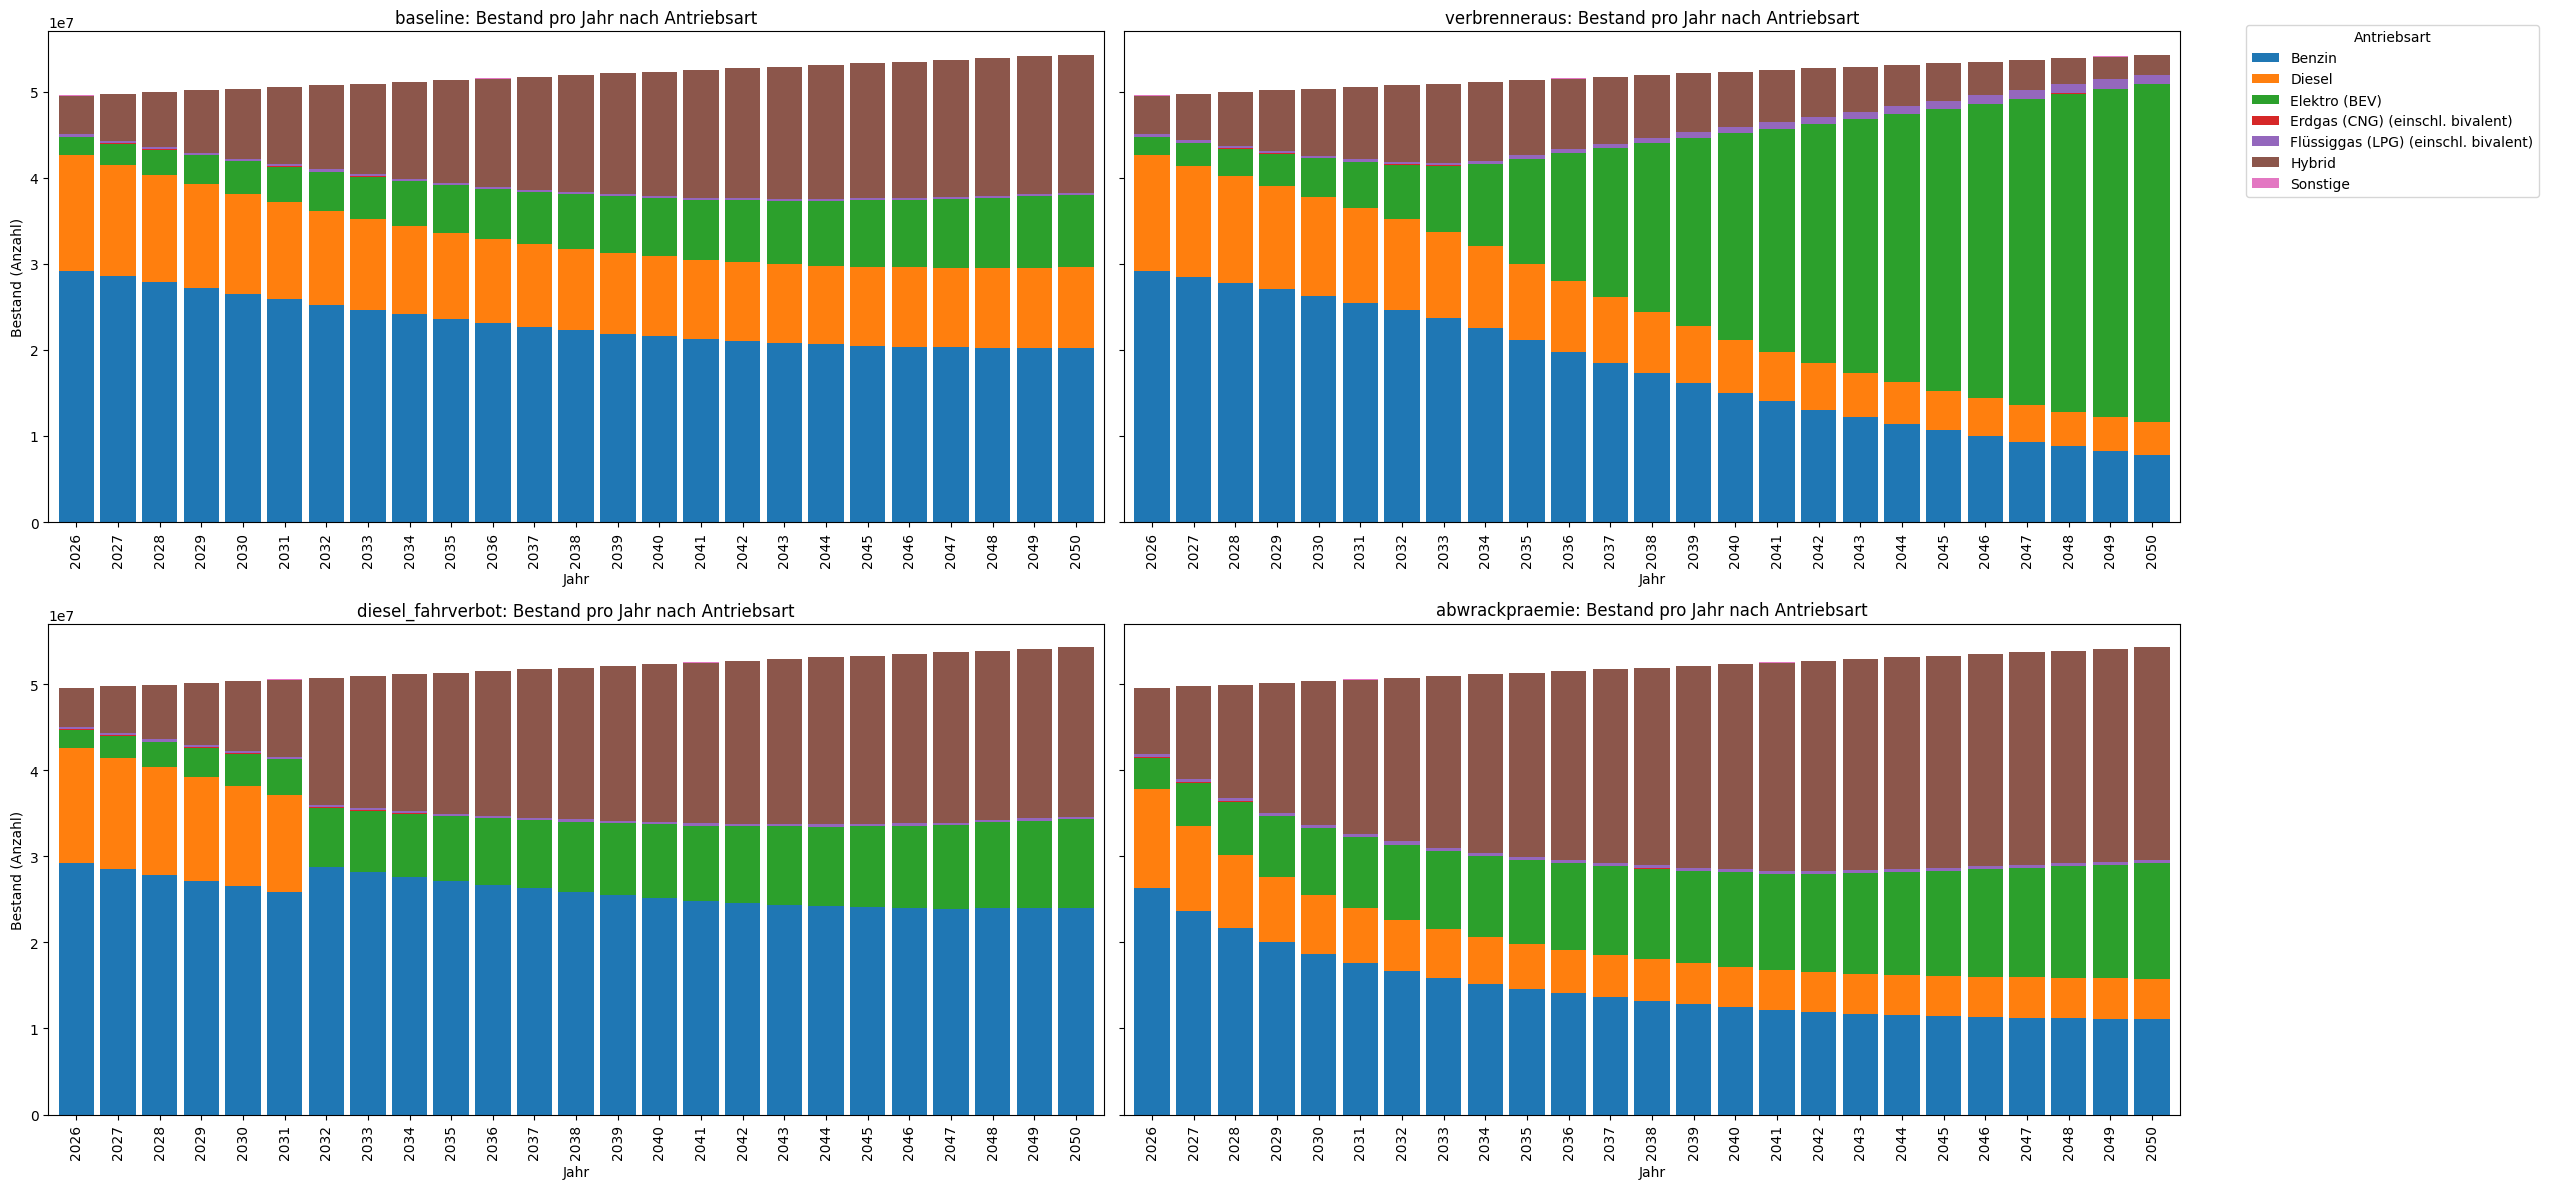

In [6]:
# =========================================
# 5) VISUALISIERUNG ALLER SZENARIEN
# =========================================
import math

scenarios = list(scenario_results.keys())
n = len(scenarios)
ncols = 2 if n > 1 else 1
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(11*ncols, 6*nrows), sharey=True)
if nrows == 1 and ncols == 1:
    axes = [axes]
elif nrows == 1 or ncols == 1:
    axes = list(axes)
else:
    axes = [ax for row in axes for ax in row]

legend_handles, legend_labels = None, None

for i, scen in enumerate(scenarios):
    ax = axes[i]
    rows = []
    for y in sorted(scenario_results[scen].keys()):
        b = scenario_results[scen][y]['bestand_df'].copy()
        g = b.groupby('Antriebsart', as_index=False)['bestand'].sum()
        g['Jahr'] = y
        rows.append(g)
    plot_df = pd.concat(rows, ignore_index=True)
    pivot_df = plot_df.pivot(index='Jahr', columns='Antriebsart', values='bestand').fillna(0).sort_index()

    pivot_df.plot(kind='bar', stacked=True, width=0.85, ax=ax, legend=False)
    ax.set_title(f'{scen}: Bestand pro Jahr nach Antriebsart')
    ax.set_xlabel('Jahr')
    ax.set_ylabel('Bestand (Anzahl)')

    legend_handles, legend_labels = ax.get_legend_handles_labels()

for j in range(n, len(axes)):
    axes[j].axis('off')

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, title='Antriebsart', bbox_to_anchor=(1.02, 0.98), loc='upper left')

plt.tight_layout()
plt.show()


In [7]:
scenario_results["baseline"][2026]["bestand_df"]

,Segment,Antriebsart,Jahr_der_Erstnutzung,bestand,Berichtsjahr,age
0,Geländewagen,Benzin,1990,565,2026,36
1,Geländewagen,Benzin,1991,618,2026,35
2,Geländewagen,Benzin,1992,817,2026,34
3,Geländewagen,Benzin,1993,825,2026,33
4,Geländewagen,Benzin,1994,927,2026,32
...,...,...,...,...,...,...
2959,Wohnmobile,Sonstige,2021,7,2026,5
2960,Wohnmobile,Sonstige,2022,21,2026,4
2961,Wohnmobile,Sonstige,2023,15,2026,3
2962,Wohnmobile,Sonstige,2024,17,2026,2


In [9]:
scenario_results["baseline"][2026]["entries_df"]

,Segment,Antriebsart,share_base,share_policy,entries,Jahr_der_Erstnutzung
0,Geländewagen,Benzin,0.009851,0.009851,29275,2026
1,Geländewagen,Diesel,0.017703,0.017703,52609,2026
2,Geländewagen,Elektro (BEV),0.004192,0.004192,12457,2026
3,Geländewagen,Flüssiggas (LPG) (einschl. bivalent),0.000003,0.000003,9,2026
4,Geländewagen,Hybrid,0.077099,0.077099,229120,2026
...,...,...,...,...,...,...
73,Wohnmobile,Diesel,0.024781,0.024781,73643,2026
74,Wohnmobile,Elektro (BEV),0.000017,0.000017,50,2026
75,Wohnmobile,Flüssiggas (LPG) (einschl. bivalent),0.000002,0.000002,6,2026
76,Wohnmobile,Hybrid,0.000037,0.000037,111,2026


In [10]:
scenario_results["baseline"][2026].keys()

dict_keys(['exits_df', 'reentries_df', 'missing_df', 'entries_df', 'bestand_df'])

In [11]:
scenario_results["baseline"][2026]["missing_df"]

,Jahr,target_gesamtbestand,bestand_existing,fehlende_autos
0,2026,49536523,46564774,2971749


In [8]:
pd.to_pickle(scenario_results, "/Users/maxbeihofer/Annika Exit Modell/scenario_results.pkl")